In [19]:
# ============================================
# Student Placement Prediction
# Machine Learning Project
# ============================================

# Import Libraries

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

print("=" * 60)
print("      STUDENT PLACEMENT PREDICTION SYSTEM")
print("=" * 60)
df = pd.read_csv("student_placement.csv")

# ============================================
# Checking Missing Values
# ============================================

print("\nChecking Missing Values...\n")

print(df.isnull().sum())

# ============================================
# droping unnecessary data
# ============================================
print("============================================")

df = df.drop("Student_ID", axis=1)

# ============================================
# Encode Categorical Columns
# ============================================

internship_encoder = LabelEncoder()
placement_encoder = LabelEncoder()

df["Internship"] = internship_encoder.fit_transform(df["Internship"])
df["Placement"] = placement_encoder.fit_transform(df["Placement"])

print("\nDataset After Encoding:\n")

print(df.head())

# ============================================
# Separate Features and Target
# ============================================

X = df.drop("Placement", axis=1)
y = df["Placement"]

# ============================================
#Split Dataset into Train and Test
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

      STUDENT PLACEMENT PREDICTION SYSTEM

Checking Missing Values...

Student_ID              0
CGPA                    0
IQ                      0
Communication_Skills    0
Aptitude_Score          0
Technical_Skills        0
Internship              0
Projects                0
Backlogs                0
Attendance              0
Placement               0
dtype: int64

Dataset After Encoding:

   CGPA   IQ  Communication_Skills  Aptitude_Score  Technical_Skills  \
0  9.73   81                     8              54                 6   
1  5.72  107                    10              63                 2   
2  9.48   80                     5              91                 5   
3  7.76  118                     7              98                 9   
4  6.40  134                     3              97                 6   

   Internship  Projects  Backlogs  Attendance  Placement  
0           1         0         4          97          0  
1           0         5         4          90        

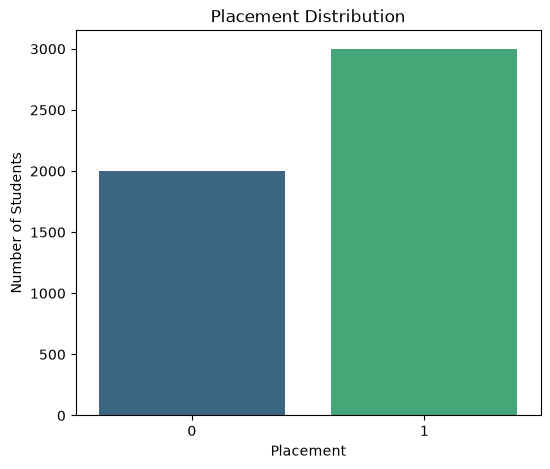

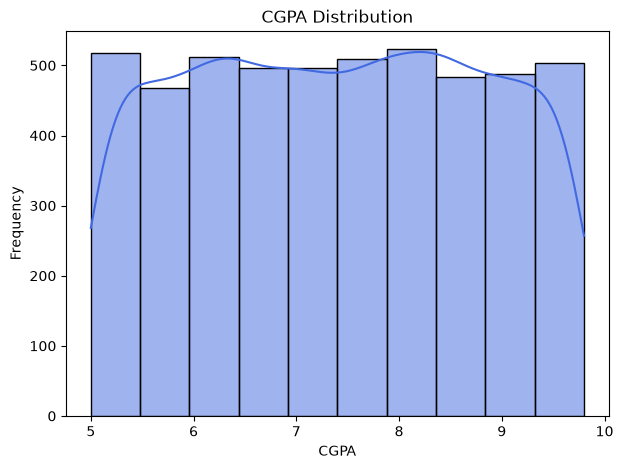

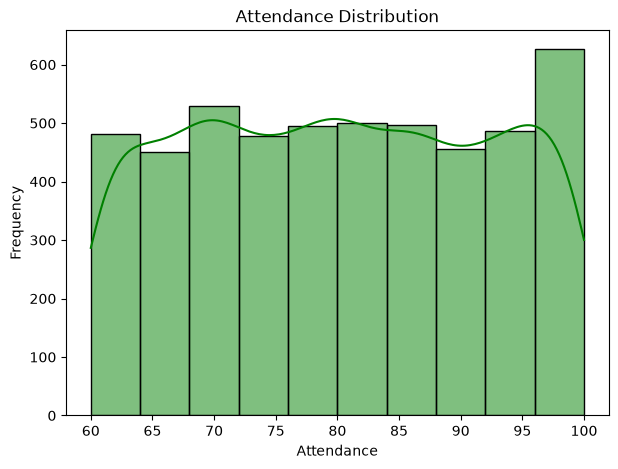

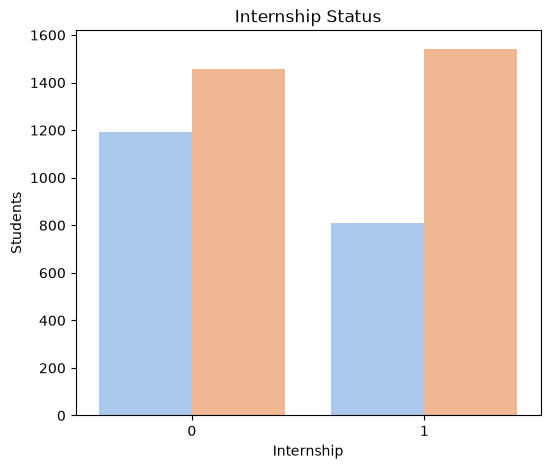

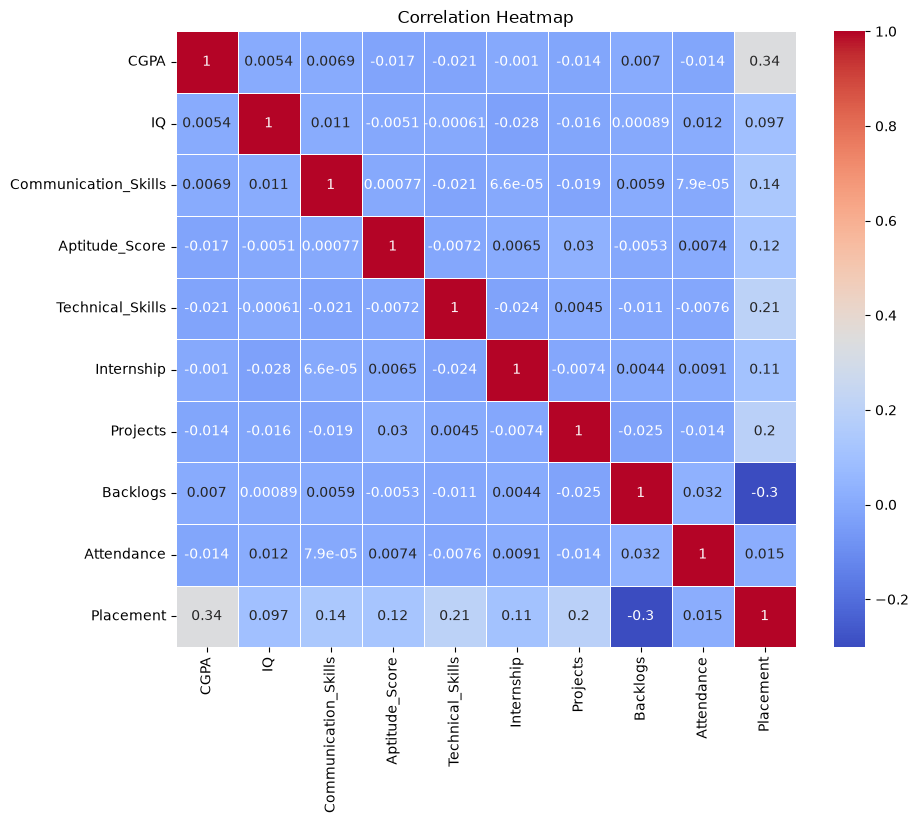

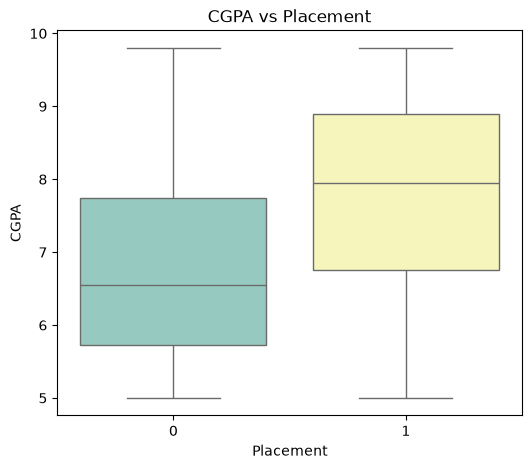

In [21]:
# ============================================
# Placement Distribution
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="Placement",
    hue="Placement",
    data=df,
    palette="viridis",
    legend=False
)

plt.title("Placement Distribution")
plt.xlabel("Placement")
plt.ylabel("Number of Students")

plt.savefig("graphs/placement_distribution")

plt.show()
# ============================================
# CGPA Distribution
# ============================================

plt.figure(figsize=(7,5))

sns.histplot(
    df["CGPA"],
    bins=10,
    kde=True,
    color="royalblue"
)

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")

plt.savefig("graphs/cgpa_distribution.png")

plt.show()

# ============================================
# Attendance Distribution
# ============================================

plt.figure(figsize=(7,5))

sns.histplot(
    df["Attendance"],
    bins=10,
    kde=True,
    color="green"
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")

plt.savefig("graphs/attendance_distribution.png")

plt.show()

# ============================================
# Internship Count
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="Internship",
    hue="Placement",
    data=df,
    palette="pastel",
    legend=False
)

plt.title("Internship Status")
plt.xlabel("Internship")
plt.ylabel("Students")

plt.savefig("graphs/internship_status.png")

plt.show()

# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("graphs/correlation_heatmap.png")

plt.show()

# ============================================
# CGPA vs Placement
# ============================================

plt.figure(figsize=(6,5))

sns.boxplot(
    x="Placement",
    hue="Placement",
    y="CGPA",
    data=df,
    palette="Set3",
    legend=False
)

plt.title("CGPA vs Placement")

plt.savefig("graphs/cgpa_vs_placement.png")

plt.show()



Logistic Regression Accuracy : 78.60%

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.69      0.72       400
           1       0.80      0.85      0.83       600

    accuracy                           0.79      1000
   macro avg       0.78      0.77      0.77      1000
weighted avg       0.78      0.79      0.78      1000


Confusion Matrix

[[276 124]
 [ 90 510]]


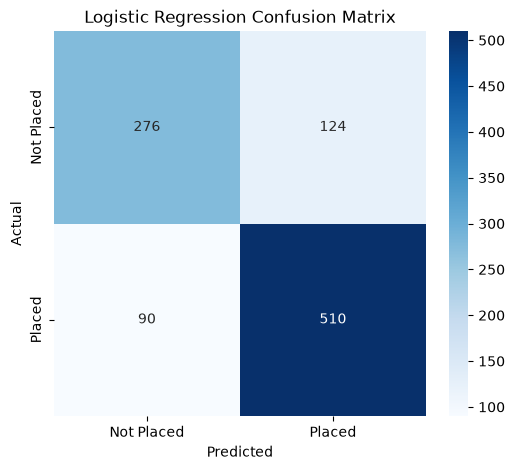


LOGISTIC REGRESSION COMPLETED SUCCESSFULLY


In [22]:
# ============================================
# Logistic Regression
# ============================================
# Dictionary to store model accuracy

model_results = {}

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

# ============================================
# Prediction
# ============================================

y_pred_lr = logistic_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
model_results["Logistic Regression"] = accuracy_lr

print("\nLogistic Regression Accuracy : {:.2f}%".format(accuracy_lr * 100))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nConfusion Matrix\n")

print(cm_lr)

# ============================================
# Confusion Matrix
# ============================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("graphs/logistic_confusion_matrix.png")

plt.show()

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION COMPLETED SUCCESSFULLY")
print("=" * 60)


Training Support Vector Machine (SVM) Model...
Support Vector Machine Model Trained Successfully!

Support Vector Machine Accuracy : 77.50%

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.65      0.70       400
           1       0.79      0.86      0.82       600

    accuracy                           0.78      1000
   macro avg       0.77      0.75      0.76      1000
weighted avg       0.77      0.78      0.77      1000


Confusion Matrix

[[259 141]
 [ 84 516]]


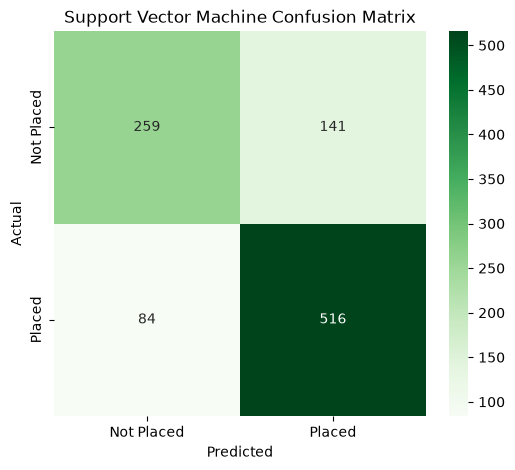


SUPPORT VECTOR MACHINE COMPLETED SUCCESSFULLY


In [23]:
# ============================================
# Support Vector Machine (SVM)
# ============================================

print("\nTraining Support Vector Machine (SVM) Model...")

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("Support Vector Machine Model Trained Successfully!")
# ============================================
# Prediction
# ============================================

y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

model_results["Support Vector Machine"] = accuracy_svm

print("\nSupport Vector Machine Accuracy : {:.2f}%".format(accuracy_svm * 100))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix\n")

print(cm_svm)

# ============================================
# SVM Confusion Matrix
# ============================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Support Vector Machine Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("graphs/svm_confusion_matrix.png")

plt.show()

print("\n" + "=" * 60)
print("SUPPORT VECTOR MACHINE COMPLETED SUCCESSFULLY")
print("=" * 60)


Finding the Best Value of K...

K = 1  ---> Accuracy = 69.30%
K = 2  ---> Accuracy = 66.70%
K = 3  ---> Accuracy = 74.70%
K = 4  ---> Accuracy = 72.40%
K = 5  ---> Accuracy = 75.00%
K = 6  ---> Accuracy = 74.60%
K = 7  ---> Accuracy = 76.50%
K = 8  ---> Accuracy = 75.80%
K = 9  ---> Accuracy = 77.10%
K = 10  ---> Accuracy = 76.90%


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

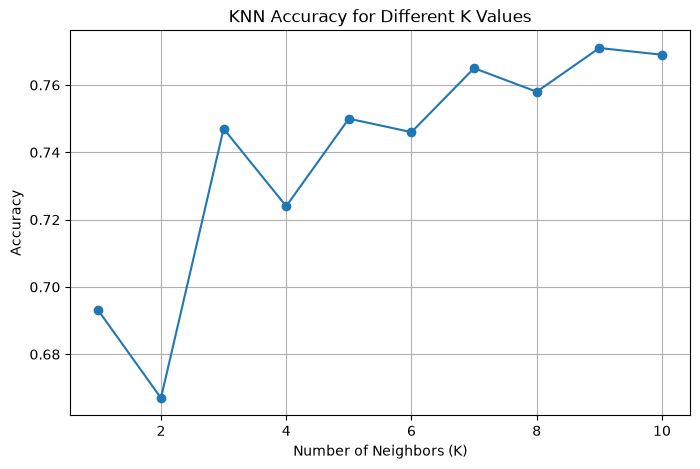


Best K Value : 9
KNN Model Trained Successfully!

KNN Accuracy : 77.10%

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.64      0.69       400
           1       0.78      0.86      0.82       600

    accuracy                           0.77      1000
   macro avg       0.77      0.75      0.75      1000
weighted avg       0.77      0.77      0.77      1000


Confusion Matrix

[[254 146]
 [ 83 517]]


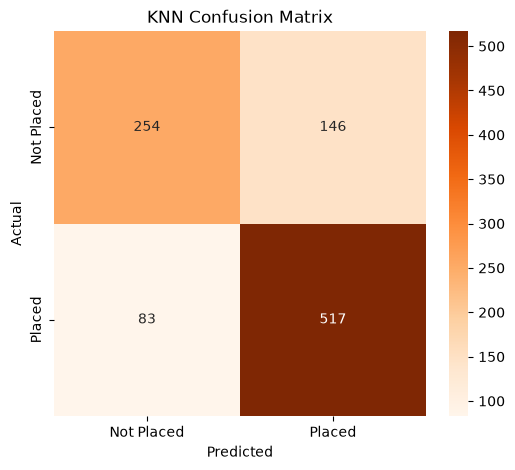


K-NEAREST NEIGHBORS COMPLETED SUCCESSFULLY


In [24]:
# ============================================
# Finding Best K for KNN
# ============================================

print("\nFinding the Best Value of K...\n")

k_values = range(1, 11)

k_accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    predictions = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    k_accuracies.append(accuracy)

    print(f"K = {k}  ---> Accuracy = {accuracy*100:.2f}%")

    plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    k_accuracies,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.grid(True)

plt.savefig("graphs/knn_k_selection.png")

plt.show()

best_k = k_accuracies.index(max(k_accuracies)) + 1

print("\nBest K Value :", best_k)

# ============================================
# KNN Model
# ============================================

knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN Model Trained Successfully!")

y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

model_results["K-Nearest Neighbors"] = accuracy_knn

print("\nKNN Accuracy : {:.2f}%".format(accuracy_knn*100))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred_knn
))

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print("\nConfusion Matrix\n")

print(cm_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Not Placed","Placed"],
    yticklabels=["Not Placed","Placed"]
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("graphs/knn_confusion_matrix.png")

plt.show()

print("\n" + "="*60)
print("K-NEAREST NEIGHBORS COMPLETED SUCCESSFULLY")
print("="*60)


Decision Tree Accuracy : 71.60%

Classification Report

              precision    recall  f1-score   support

           0       0.72      0.47      0.57       400
           1       0.71      0.88      0.79       600

    accuracy                           0.72      1000
   macro avg       0.72      0.68      0.68      1000
weighted avg       0.72      0.72      0.70      1000


Confusion Matrix

[[190 210]
 [ 74 526]]


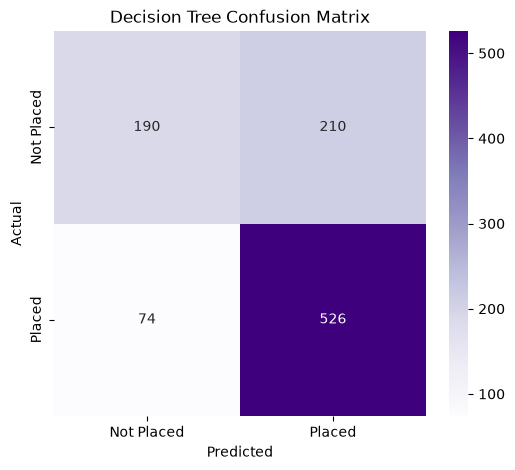


DECISION TREE COMPLETED SUCCESSFULLY


In [25]:
# ============================================
# Decision Tree Classifier
# ============================================

decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

# ============================================
# Prediction
# ============================================

y_pred_dt = decision_tree_model.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

model_results["Decision Tree"] = accuracy_dt

print("\nDecision Tree Accuracy : {:.2f}%".format(accuracy_dt * 100))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred_dt
))

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print("\nConfusion Matrix\n")

print(cm_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("graphs/decision_tree_confusion_matrix.png")

plt.show()

print("\n" + "="*60)
print("DECISION TREE COMPLETED SUCCESSFULLY")
print("="*60)

In [1]:
# ============================================
# Model Comparison
# ============================================

comparison_df = pd.DataFrame({
    "Algorithm": model_results.keys(),
    "Accuracy (%)": [accuracy * 100 for accuracy in model_results.values()]
})

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison_df)

best_model = comparison_df.loc[
    comparison_df["Accuracy (%)"].idxmax()
]

print("\n")
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Algorithm : {best_model['Algorithm']}")
print(f"Accuracy  : {best_model['Accuracy (%)']:.2f}%")

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Accuracy (%)"]
)

plt.title("Comparison of Machine Learning Models")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy (%)")

plt.ylim(0,110)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        fontsize=10
    )

plt.savefig("graphs/model_comparison.png")

plt.show()

ranking = comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\n")
print("=" * 60)
print("MODEL RANKING")
print("=" * 60)

print(ranking)

print("\n")
print("=" * 60)
print("PROJECT CONCLUSION")
print("=" * 60)


NameError: name 'pd' is not defined

In [28]:
print(f"""
Among all the machine learning algorithms,
{best_model['Algorithm']} achieved the highest accuracy
of {best_model['Accuracy (%)']:.2f}% on the Student Placement dataset.

The comparison indicates that different machine learning
algorithms perform differently depending on the nature
of the dataset.

Therefore,
{best_model['Algorithm']}
is selected as the best model for predicting
student placement in this project.
""")

joblib.dump(
    knn_model,
    "knn_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)


Among all the machine learning algorithms,
Logistic Regression achieved the highest accuracy
of 78.60% on the Student Placement dataset.

The comparison indicates that different machine learning
algorithms perform differently depending on the nature
of the dataset.

Therefore,
Logistic Regression
is selected as the best model for predicting
student placement in this project.



['scaler.pkl']